In [ ]:
# CELL 1: Cài đặt các thư viện mới nhất để dùng LangGraph với Vertex AI
!pip install -qU langgraph langchain-google-vertexai pandas matplotlib fastapi uvicorn pyngrok nest-asyncio

In [ ]:
# /content/gen-lang-client-0568569180-715176037deb.json   path
# gen-lang-client-0568569180  :  project_id

In [ ]:
import os
from getpass import getpass
from langchain_google_vertexai import ChatVertexAI

# 1. Thiết lập xác thực (Giữ nguyên tư duy của bạn)
key_path = getpass("Nhập đường dẫn file JSON Service Account: ")
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = key_path

project_id = getpass("Nhập Google Cloud Project ID: ")
os.environ["GOOGLE_CLOUD_PROJECT"] = project_id

# 2. Khởi tạo Model thông qua lớp ChatVertexAI (thay vì GenerativeModel)
# Đây là "trái tim" sẽ được bỏ vào các Node của LangGraph
llm = ChatVertexAI(
    model_name="gemini-2.5-flash",
    location="us-central1",
    temperature=0,
    max_output_tokens=2048,
)

In [4]:
response = llm.invoke("Chào bạn, bạn đã sẵn sàng làm việc trong hệ thống Multi-Agent chưa?")
print("Test Model:", response.content)

Test Model: Chào bạn! Tuyệt vời! Với tư cách là một mô hình AI, tôi luôn sẵn sàng và được thiết kế để tương tác, xử lý thông tin và thực hiện các tác vụ trong nhiều môi


In [8]:
from typing import TypedDict, Optional, List
import pandas as pd

# This class defines the shared memory (State) for our Multi-Agent system.
# Each Agent (Node) will read from this and update the fields they are responsible for.
class AnalysisState(TypedDict):
    # 1. The original question from the user
    question: str

    # 2. Detailed schema generated by the Schema Agent (columns, types, samples)
    schema: str

    # 3. The SQL code generated by the SQL Agent
    sql_query: str

    # 4. The raw data results from the database (Pandas DataFrame)
    result_df: Optional[pd.DataFrame]

    # 5. The type of chart chosen (bar, line, scatter, or none)
    chart_type: str

    # 6. The final business summary written by the Insight Agent
    insight: str

    # 7. Error messages (if any) to help the system recover or inform the user
    error: Optional[str]

print("✅ AnalysisState defined successfully!")

✅ AnalysisState defined successfully!


In [10]:
import sqlite3
import pandas as pd
import io
from google.colab import files

# 1. Provide a way to get the data
# You can choose to use the Sample Data or Upload your own
print("Choose an option:")
print("1. Use Sample Traffic Data")
print("2. Upload your own CSV")

choice = input("Enter 1 or 2: ")

if choice == '2':
    uploaded = files.upload()
    if uploaded:
        file_name = list(uploaded.keys())[0]
        df = pd.read_csv(io.BytesIO(uploaded[file_name]))
        print(f"✅ Loaded: {file_name}")
    else:
        print("No file uploaded, falling back to sample data.")
        choice = '1'

if choice == '1' or not uploaded:
    df = pd.DataFrame({
        "date":     ["2024-01", "2024-02", "2024-03", "2024-04", "2024-05"],
        "product":  ["Widget A", "Widget B", "Widget A", "Widget C", "Widget B"],
        "region":   ["North", "South", "East", "West", "North"],
        "sales":    [1200, 850, 1450, 630, 970],
        "units":    [120, 85, 145, 63, 97],
        "profit":   [240, 170, 290, 126, 194],
    })
    print("✅ Using sample sales data.")

# 2. SQLite Configuration (from your high-quality code snippet)
TABLE_NAME = "dataset"

def build_sqlite_connection(dataframe: pd.DataFrame) -> sqlite3.Connection:
    """Create an in-memory SQLite DB and load the DataFrame into it."""
    # check_same_thread=False is crucial for multi-agent systems
    conn = sqlite3.connect(":memory:", check_same_thread=False)
    dataframe.to_sql(TABLE_NAME, conn, index=False, if_exists="replace")
    return conn

# Create the global connection object
db_conn = build_sqlite_connection(df)

def db_query(query: str):
    """Execution helper for the agents."""
    try:
        return pd.read_sql_query(query, db_conn)
    except Exception as e:
        return str(e)

print(f"✅ SQLite Database initialized. Table name: '{TABLE_NAME}'")
print(f"Schema columns: {df.columns.tolist()}")

Choose an option:
1. Use Sample Traffic Data
2. Upload your own CSV
Enter 1 or 2: 2


Saving emnist-balanced-test.csv to emnist-balanced-test.csv
✅ Loaded: emnist-balanced-test.csv
✅ SQLite Database initialized. Table name: 'dataset'
Schema columns: ['41', '0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '0.10', '0.11', '0.12', '0.13', '0.14', '0.15', '0.16', '0.17', '0.18', '0.19', '0.20', '0.21', '0.22', '0.23', '0.24', '0.25', '0.26', '0.27', '0.28', '0.29', '0.30', '0.31', '0.32', '0.33', '0.34', '0.35', '0.36', '0.37', '0.38', '0.39', '0.40', '0.41', '0.42', '0.43', '0.44', '0.45', '0.46', '0.47', '0.48', '0.49', '0.50', '0.51', '0.52', '0.53', '0.54', '0.55', '0.56', '0.57', '0.58', '0.59', '0.60', '0.61', '0.62', '0.63', '0.64', '0.65', '0.66', '0.67', '0.68', '0.69', '0.70', '0.71', '0.72', '0.73', '0.74', '0.75', '0.76', '0.77', '0.78', '0.79', '0.80', '0.81', '0.82', '0.83', '0.84', '0.85', '0.86', '0.87', '0.88', '0.89', '0.90', '0.91', '0.92', '0.93', '0.94', '0.95', '0.96', '0.97', '0.98', '0.99', '0.100', '0.101', '0.102', '0.103', '0.10

In [11]:
import re
import textwrap
from langchain_core.messages import HumanMessage

# ── 1. Schema Agent ─────────────────────────────────────────────
def schema_agent(state: AnalysisState) -> AnalysisState:
    """
    Reads the global DataFrame and produces a detailed schema description.
    This helps the SQL Agent understand the context without guessing.
    """
    # We use the global 'df' and 'TABLE_NAME' from Cell 4
    lines = [f"Table name: {TABLE_NAME}"]
    lines.append(f"Row count : {len(df)}")
    lines.append("Columns:")

    for col, dtype in df.dtypes.items():
        # Get a non-null sample value to show the Agent the format
        sample = df[col].dropna().iloc[0] if not df[col].dropna().empty else "N/A"
        lines.append(f"  - {col} ({dtype}) e.g. {sample!r}")

    schema_str = "\n".join(lines)
    print(f"[SchemaAgent] Schema prepared for {len(df)} rows.")

    # We update the 'schema' field in our AnalysisState
    return {**state, "schema": schema_str}


# ── 2. SQL Agent ────────────────────────────────────────────────
def sql_agent(state: AnalysisState) -> AnalysisState:
    """
    Converts the user question into a valid SQLite query using the schema.
    """
    # We use textwrap.dedent to keep the prompt clean and aligned
    prompt = textwrap.dedent(f"""
        You are an expert SQL assistant. Given the schema below, write a
        single valid SQLite SELECT query that answers the user's question.

        Schema Context:
        {state['schema']}

        User Question: {state['question']}

        Rules:
        - Output ONLY the raw SQL query.
        - No markdown fences (like ```sql), no explanations.
        - Use the exact table name: {TABLE_NAME}
        - Only use SQLite compatible features.
    """).strip()

    # Call Gemini (the 'llm' instance from Cell 2)
    response = llm.invoke([HumanMessage(content=prompt)])
    raw_output = response.content.strip()

    # Regex Cleaning: Remove any accidental markdown fences the LLM might add
    sql_query = re.sub(r"^```[a-z]*\n?|```$", "", raw_output, flags=re.MULTILINE).strip()

    print(f"[SQLAgent] Generated SQL:\n{sql_query}")

    # Update 'sql_query' in state
    return {**state, "sql_query": sql_query}

print("✅ Schema Agent and SQL Agent are ready!")

✅ Schema Agent and SQL Agent are ready!


In [15]:
import matplotlib.pyplot as plt

# ── 3. Execution Tool ───────────────────────────────────────────
def execution_tool(state: AnalysisState) -> AnalysisState:
    """Executes the SQL query and stores the result."""
    query = state["sql_query"]

    # Check if the Agent refused to answer
    if "ERROR" in query:
        return {**state, "error": query, "result_df": None}

    try:
        # We use the db_query helper from Cell 4
        result = db_query(query)
        print(f"[ExecutionTool] Success: {len(result)} rows returned.")
        return {**state, "result_df": result, "error": None}
    except Exception as e:
        print(f"[ExecutionTool] Error: {str(e)}")
        return {**state, "result_df": pd.DataFrame(), "error": str(e)}

# ── 4. Visualization Agent ──────────────────────────────────────
def visualization_agent(state: AnalysisState) -> AnalysisState:
    """Decides on chart type and renders the plot."""
    result_df = state.get("result_df")

    if result_df is None or result_df.empty or state.get("error"):
        return {**state, "chart_type": "none"}

    # Ask LLM to choose chart type based on the results
    prompt = f"""
    You are a Data Viz expert. Look at this data preview:
    {result_df.head(5).to_string()}

    Choose the best chart type: bar, line, scatter, or none.
    Respond with exactly ONE word.
    """

    response = llm.invoke([HumanMessage(content=prompt)])
    chart_type = response.content.strip().lower()

    # Call the actual plotting function
    _render_chart(result_df, chart_type)

    return {**state, "chart_type": chart_type}

def _render_chart(df, chart_type):
    """Internal helper to save the figure."""
    if chart_type == "none" or df.empty:
        return

    try:
        # Identify numeric vs categorical columns
        num_cols = df.select_dtypes(include='number').columns.tolist()
        cat_cols = df.select_dtypes(exclude='number').columns.tolist()

        plt.figure(figsize=(10, 6))
        x_axis = cat_cols[0] if cat_cols else df.columns[0]
        y_axis = num_cols[0] if num_cols else df.columns[-1]

        if chart_type == "bar":
            plt.bar(df[x_axis].astype(str), df[y_axis], color='skyblue')
        elif chart_type == "line":
            plt.plot(df[x_axis].astype(str), df[y_axis], marker='o', linestyle='-')
        elif chart_type == "scatter":
            plt.scatter(df[x_axis], df[y_axis])

        plt.title(f"Analysis: {y_axis} by {x_axis}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig("chart_output.png")
        plt.close()
        print(f"[VizAgent] Chart saved as chart_output.png (Type: {chart_type})")
    except Exception as e:
        print(f"Visualization failed: {e}")

print("✅ Execution and Visualization nodes are ready!")

✅ Execution and Visualization nodes are ready!


--- Running Execution Tool ---
[ExecutionTool] Success: 47 rows returned.
Data retrieved successfully! (First 5 rows):
   41  COUNT(*)
0   0       400
1   1       400
2   2       400
3   3       400
4   4       400

--- Running Visualization Agent ---
[VizAgent] Chart saved as chart_output.png (Type: bar)
Agent chose chart type: bar

✅ Chart successfully generated and saved!


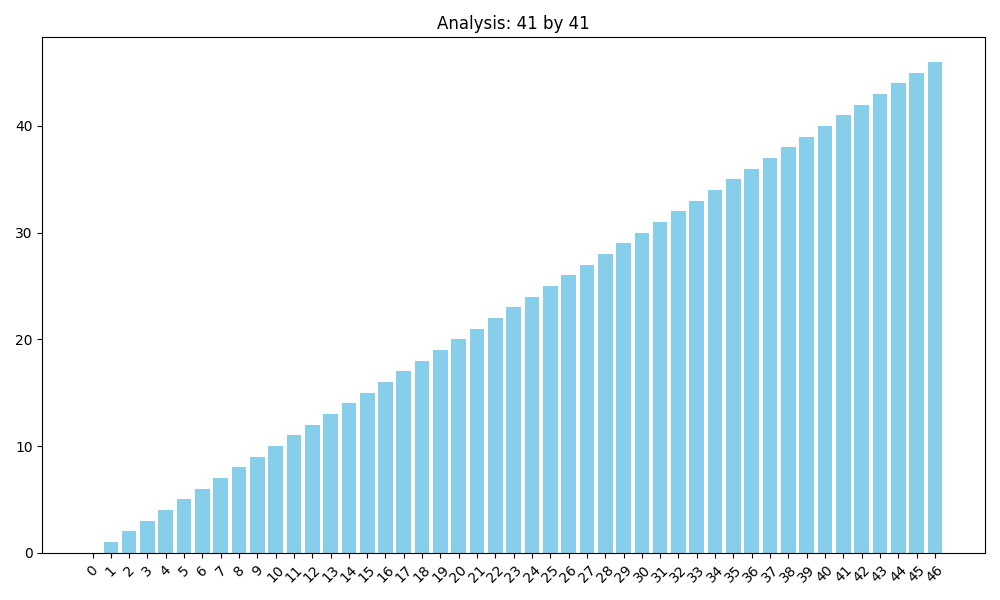

In [16]:
# 1. Manually prepare a state with the SQL query you just validated
test_state_cell6: AnalysisState = {
    "question": "How many rows are there for each label in column '41'?",
    "schema": "", # Not needed for these nodes
    "sql_query": 'SELECT "41", COUNT(*) FROM dataset GROUP BY "41"', # The valid SQL from your test
    "result_df": None,
    "chart_type": "",
    "insight": "",
    "error": None
}

# 2. Run Execution Tool (This will query your SQLite DB)
print("--- Running Execution Tool ---")
test_state_cell6 = execution_tool(test_state_cell6)

if test_state_cell6["result_df"] is not None:
    print(f"Data retrieved successfully! (First 5 rows):\n{test_state_cell6['result_df'].head()}")
else:
    print(f"Execution failed: {test_state_cell6['error']}")

# 3. Run Visualization Agent (This will call Gemini to pick chart type and save PNG)
print("\n--- Running Visualization Agent ---")
test_state_cell6 = visualization_agent(test_state_cell6)

print(f"Agent chose chart type: {test_state_cell6['chart_type']}")

# 4. Check and Display the output image
import os
from IPython.display import Image, display

if os.path.exists("chart_output.png"):
    print("\n✅ Chart successfully generated and saved!")
    display(Image("chart_output.png"))
else:
    print("\n❌ No chart image found. Check the _render_chart logic.")

In [17]:
def insight_agent(state: AnalysisState) -> AnalysisState:
    """
    Summarize the data results into a 2-3 sentence business insight.
    """
    result_df = state.get("result_df")
    error = state.get("error")

    # If there was an error in previous steps, report it
    if error:
        return {**state, "insight": f"I encountered an error and cannot provide insights: {error}"}

    if result_df is None or result_df.empty:
        return {**state, "insight": "The query returned no data, so there are no insights to share."}

    # Prepare data context for the LLM
    # We convert the top results to a string so Gemini can "read" it
    data_preview = result_df.head(10).to_string(index=False)

    prompt = textwrap.dedent(f"""
        You are a Senior Data Analyst.
        The user asked: "{state['question']}"
        The SQL query returned the following results:
        {data_preview}

        Task: Write a 2-3 sentence summary of the key findings.
        Rules:
        - Be professional, concise, and insightful.
        - Mention specific numbers if they are significant.
        - Do not use markdown headers or bullet points.
    """).strip()

    response = llm.invoke([HumanMessage(content=prompt)])
    insight = response.content.strip()

    print("[InsightAgent] Business summary generated.")
    return {**state, "insight": insight}

print("✅ Insight Agent is ready!")

✅ Insight Agent is ready!


In [18]:
from langgraph.graph import StateGraph, END

def build_graph() -> StateGraph:
    # 1. Create the graph with our shared AnalysisState
    workflow = StateGraph(AnalysisState)

    # 2. Register all our Nodes (The functions we wrote in Cells 5, 6, 7)
    workflow.add_node("schema_builder", schema_agent)
    workflow.add_node("sql_generator",  sql_agent)
    workflow.add_node("data_executor",  execution_tool)
    workflow.add_node("viz_designer",   visualization_agent)
    workflow.add_node("insight_writer", insight_agent)

    # 3. Set the starting point
    workflow.set_entry_point("schema_builder")

    # 4. Define the sequence of execution (Edges)
    workflow.add_edge("schema_builder", "sql_generator")
    workflow.add_edge("sql_generator",  "data_executor")
    workflow.add_edge("data_executor",  "viz_designer")
    workflow.add_edge("viz_designer",   "insight_writer")
    workflow.add_edge("insight_writer", END)

    # 5. Compile the graph into a single executable object
    return workflow.compile()

# Instantiate the pipeline
analyst_app = build_graph()
print("✅ Pipeline compiled successfully! Your Multi-Agent system is LIVE.")

✅ Pipeline compiled successfully! Your Multi-Agent system is LIVE.


In [ ]:
# Test with your EMNIST-like dataset
user_input = {
    "question": "Show me the count for each category in column '41' and tell me which one is the most frequent.",
    "schema": "",
    "sql_query": "",
    "result_df": None,
    "chart_type": "",
    "insight": "",
    "error": None
}

# Execute the entire workflow
final_result = analyst_app.invoke(user_input)

# Display everything
print("\n" + "🚀" * 15)
print("FINAL ANALYST REPORT")
print("-" * 30)
print(f"SQL QUERY:\n{final_result['sql_query']}")
print(f"\nINSIGHT:\n{final_result['insight']}")
print(f"\nCHART TYPE: {final_result['chart_type']}")
print("🚀" * 15)

# Show the chart if it exists
if os.path.exists("chart_output.png"):
    display(Image("chart_output.png"))

In [20]:
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from typing import Any, Optional
import uvicorn
import threading
import nest_asyncio
import json

# 1. Define the Request/Response structure (Pydantic models)
class AnalyzeRequest(BaseModel):
    question: str

class AnalyzeResponse(BaseModel):
    sql: str
    chart_type: str
    insight: str
    data_preview: Any
    error: Optional[str] = None

# 2. Initialize FastAPI app
app = FastAPI(title="Multi-Agent Data Analyst API")

@app.post("/analyze", response_model=AnalyzeResponse)
async def analyze(request: AnalyzeRequest):
    if not request.question.strip():
        raise HTTPException(status_code=400, detail="Question is empty")

    # Initial state for the Graph
    initial_state = {
        "question": request.question,
        "schema": "",
        "sql_query": "",
        "result_df": None,
        "chart_type": "",
        "insight": "",
        "error": None,
    }

    try:
        # EXECUTE THE LANGGRAPH PIPELINE
        final_state = analyst_app.invoke(initial_state)

        # Prepare data preview (convert DataFrame to JSON-friendly format)
        df_result = final_state.get("result_df")
        data_json = []
        if df_result is not None and not df_result.empty:
            data_json = json.loads(df_result.head(10).to_json(orient="records"))

        return AnalyzeResponse(
            sql=final_state.get("sql_query", ""),
            chart_type=final_state.get("chart_type", "none"),
            insight=final_state.get("insight", ""),
            data_preview=data_json,
            error=final_state.get("error")
        )
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

# 3. Background Server Runner for Colab
def run_server():
    nest_asyncio.apply()
    uvicorn.run(app, host="0.0.0.0", port=8000)

# Start the server in a separate thread so it doesn't block Colab
threading.Thread(target=run_server, daemon=True).start()
print("🚀 FastAPI Server is running on port 8000!")

🚀 FastAPI Server is running on port 8000!


In [ ]:
from pyngrok import ngrok
import time

# 1. Dọn dẹp: Đóng toàn bộ các tunnel đang chạy ngầm
print("Closing existing tunnels...")
ngrok.kill()
time.sleep(2) # Đợi 2 giây để hệ thống giải phóng port

# 2. Thiết lập Token (Thay bằng token của bạn)
NGROK_TOKEN = "3ATBxslRrhyy9lNhAx0BjesQ8Ff_6eDY7g6UhU1khJ6qtwmtY"
ngrok.set_auth_token(NGROK_TOKEN)

# 3. Kết nối lại
try:
    public_url = ngrok.connect(8000)
    print(f"🔗 Public API URL: {public_url.public_url}")
except Exception as e:
    print(f"❌ Vẫn còn lỗi: {e}")